# Figure 6

# Setup

## imports

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cProfile import label

from dms_3d_features.plotting import *

## load data

In [229]:
DATA_PATH = "../../farfar-models"

In [230]:
df = pd.read_csv(f"{DATA_PATH}/csvs/ag_pair_train_analysis.csv")
df_test = pd.read_csv(
    f"{DATA_PATH}/csvs/ag_pair_test_analysis.csv"
)
df_rmsd = pd.read_json(f"{DATA_PATH}/summary/ag_pairs_train_summary.json")
df_test_rmsd = pd.read_json(
    f"{DATA_PATH}/summary/ag_pairs_test_summary.json"
)

# Plotting

## Training 

In [231]:
df_sub = df.query("percent_true_no_cst < 80").copy()
df_test_sub = df_test.query("percent_true_no_cst < 80").copy()
not_well_refined = list(df_sub["motif"])
not_well_refined_test = list(df_test_sub["motif"])

### figure 6b: rmsd funnel

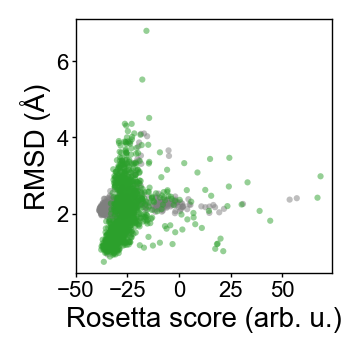

In [232]:
row = df_rmsd.query("motif == 'GGAC_GGAC'").iloc[0]
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)
ax.scatter(
    row["no_constraint"]["all_models"]["score"],
    row["no_constraint"]["all_models"]["rmsd"],
    alpha=0.5,
    s=5,
    color="tab:gray",
    edgecolors="none",
    marker="o",
)
ax.scatter(
    row["with_constraint"]["all_models"]["score"],
    row["with_constraint"]["all_models"]["rmsd"],
    alpha=0.5,
    edgecolors="none",
    s=5,
    color="tab:green",
)
publication_style_ax(ax)
ax.set_xticks([-50, -25, 0, 25, 50])
ax.set_ylabel("RMSD (Å)", labelpad=2)
ax.set_xlabel("Rosetta score (arb. u.)", labelpad=2)
plt.savefig("../../figures/figure-6b.png", dpi=300, bbox_inches="tight")

### figure 6c: rmsd comparision

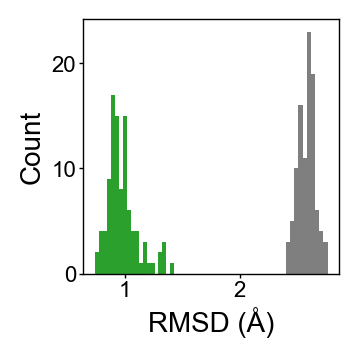

In [233]:
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)
ax.hist(
    row["with_constraint"]["top100_models"]["rmsd"],
    bins=20,
    color="tab:green",
)
ax.hist(
    row["no_constraint"]["top100_models"]["rmsd"],
    bins=10,
    color="tab:gray",
)
ax.set_xlabel("RMSD (Å)", labelpad=2)
ax.set_ylabel("Count", labelpad=2)
publication_style_ax(ax)
plt.savefig("../../figures/figure-6c.png", dpi=300, bbox_inches="tight")

### figure 6d: native bp type recovery for train set

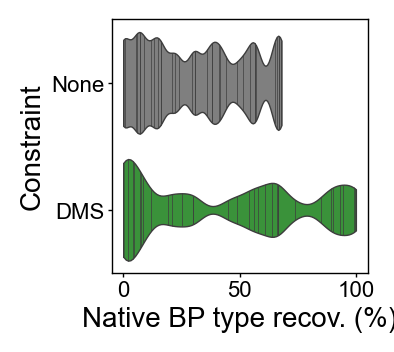

In [234]:
df_long = df_sub.melt(
    id_vars="motif",
    value_vars=["percent_true_with_cst", "percent_true_no_cst"],
    var_name="type",
    value_name="accuracy",
)
df_long["Constraint"] = df_long["type"].map(
    {
        "percent_true_with_cst": "DMS",
        "percent_true_no_cst": "None",
    }
)
colors = {"None": "tab:gray", "DMS": "tab:green"}
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)
ax = sns.violinplot(
    x="accuracy",
    y="Constraint",
    data=df_long,
    hue="Constraint",
    ax=ax,
    linewidth=0.5,
    cut=0,
    bw_adjust=0.25,
    inner="stick",
    inner_kws=dict(linewidth=0.25),
    order=["None", "DMS"],
    palette=colors,
)
publication_style_ax(ax)
ax.set_ylabel("Constraint", labelpad=2)
ax.set_xlabel("Native BP type recov. (%)", labelpad=2)
plt.savefig("../../figures/figure-6d.png", dpi=300, bbox_inches="tight")

### figure 6d: rmsd of G-A pairs for train set

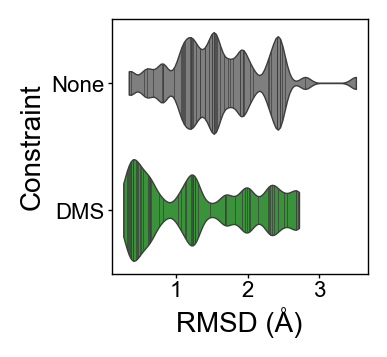

In [235]:
data = []
for i, row in df_rmsd.iterrows():
    if row["motif"] not in not_well_refined:
        continue
    for key, pair in row["with_constraint"].items():
        if not key.startswith("pair"):
            continue
        if pair["mean_rmsd"] > 4:
            continue
        data.append([pair["mean_rmsd"], "DMS"])
for i, row in df_rmsd.iterrows():
    if row["motif"] not in not_well_refined:
        continue
    for key, pair in row["no_constraint"].items():
        if not key.startswith("pair"):
            continue
        data.append([pair["mean_rmsd"], "None"])
df_compare = pd.DataFrame(data, columns=["RMSD", "Constraint"])
colors = {"None": "tab:gray", "DMS": "tab:green"}
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)
ax = sns.violinplot(
    x="RMSD",
    y="Constraint",
    data=df_compare,
    hue="Constraint",
    ax=ax,
    linewidth=0.5,
    cut=0,
    bw_adjust=0.25,
    inner="stick",
    inner_kws=dict(linewidth=0.25),
    order=["None", "DMS"],
    palette=colors,
)
publication_style_ax(ax)
ax.set_ylabel("Constraint", labelpad=2)
ax.set_xlabel("RMSD (Å)", labelpad=2)
plt.savefig("../../figures/figure-6e.png", dpi=300, bbox_inches="tight")

## Test

### figure 6e: native bp type recovery of G-A pairs for test set

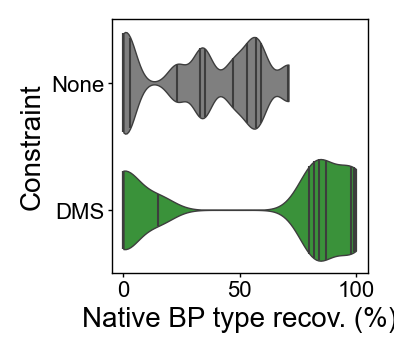

In [236]:
df_long = df_test_sub.melt(
    id_vars="motif",
    value_vars=["percent_true_with_cst", "percent_true_no_cst"],
    var_name="type",
    value_name="accuracy",
)
df_long["type"] = df_long["type"].map(
    {
        "percent_true_with_cst": "DMS",
        "percent_true_no_cst": "None",
    }
)
colors = {"None": "tab:gray", "DMS": "tab:green"}
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)
ax = sns.violinplot(
    x="accuracy",
    y="type",
    data=df_long,
    hue="type",
    ax=ax,
    linewidth=0.5,
    cut=0,
    bw_adjust=0.25,
    inner="stick",
    inner_kws=dict(linewidth=0.75),
    order=["None", "DMS"],
    palette=colors,
)
ax.set_ylabel("Constraint", labelpad=2)
ax.set_xlabel("Native BP type recov. (%)", labelpad=2)
publication_style_ax(ax)
fig.savefig("../../figures/figure-6e.png", dpi=300, bbox_inches="tight")

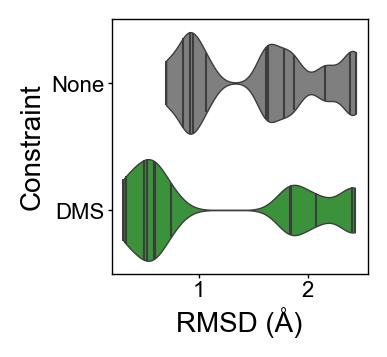

In [237]:
data = []
for i, row in df_test_rmsd.iterrows():
    if row["motif"] not in not_well_refined_test:
        continue
    for key, pair in row["with_constraint"].items():
        if not key.startswith("pair"):
            continue
        data.append([pair["mean_rmsd"], "DMS"])
for i, row in df_test_rmsd.iterrows():
    if row["motif"] not in not_well_refined_test:
        continue
    for key, pair in row["no_constraint"].items():
        if not key.startswith("pair"):
            continue
        data.append([pair["mean_rmsd"], "None"])
df_compare = pd.DataFrame(data, columns=["RMSD", "Constraint"])
colors = {"None": "tab:gray", "DMS": "tab:green"}
fig, ax = plt.subplots(figsize=(1.65, 1.65), dpi=200)
ax = sns.violinplot(
    x="RMSD",
    y="Constraint",
    data=df_compare,
    hue="Constraint",
    ax=ax,
    linewidth=0.5,
    cut=0,
    bw_adjust=0.25,
    inner="stick",
    inner_kws=dict(linewidth=0.75),
    order=["None", "DMS"],
    palette=colors,
)
publication_style_ax(ax)
ax.set_ylabel("Constraint", labelpad=2)
ax.set_xlabel("RMSD (Å)", labelpad=2)
plt.savefig("../../figures/figure-6f.png", dpi=300, bbox_inches="tight")